# Employee Attrition Risk Analytics

Notebook 1: Data Audit & Exploratory Data Analysis

This notebook performs the initial analysis of the IBM HR Analytics Employee Attrition dataset. The objective is to understand the data, assess its quality, identify potential issues, and uncover business insights that influence employee attrition.

The findings from this notebook will guide feature engineering and predictive model development in subsequent notebooks.

In [51]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)

# Plot settings
plt.style.use("ggplot")

In [52]:
df = pd.read_csv(r"C:\Users\Saraa Jaitly\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [53]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [54]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 1470
Columns : 35


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [56]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [57]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [58]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [59]:
df.dtypes.value_counts()

int64     26
object     9
Name: count, dtype: int64

In [60]:
pd.DataFrame({
    "Unique Values": df.nunique()
}).sort_values("Unique Values")

,Unique Values
EmployeeCount,1
Over18,1
StandardHours,1
Attrition,2
OverTime,2
PerformanceRating,2
Gender,2
BusinessTravel,3
Department,3
MaritalStatus,3


In [61]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [62]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

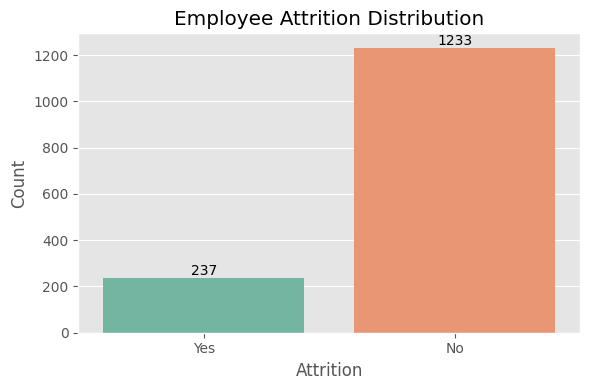

In [63]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="Attrition", palette="Set2")

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

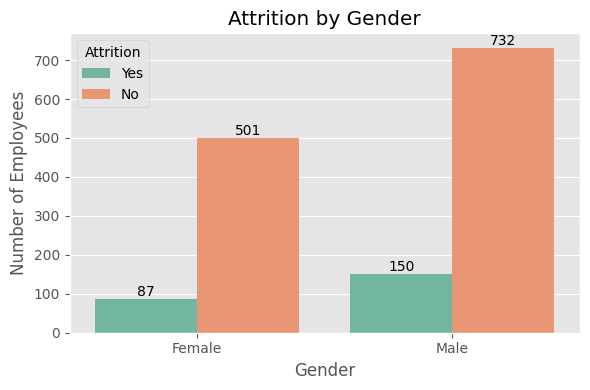

In [64]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Gender",
    hue="Attrition",
    palette="Set2"
)

plt.title("Attrition by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Employees")

for container in ax.containers:
    ax.bar_label(container)

plt.legend(title="Attrition")
plt.tight_layout()
plt.show()

In [65]:
pd.crosstab(
    df["Gender"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
Gender,,
Female,85.204082,14.795918
Male,82.993197,17.006803


In [66]:
pd.crosstab(
    df["OverTime"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


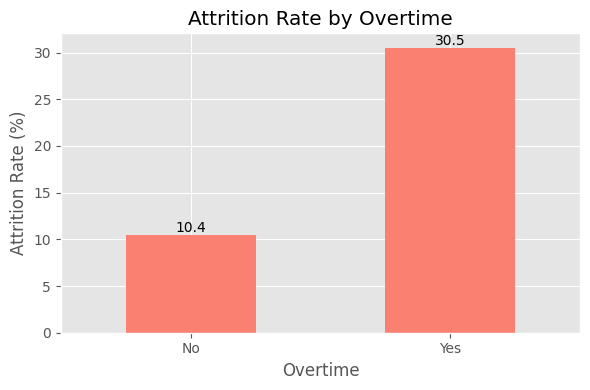

In [67]:
overtime_rate = (
    pd.crosstab(df["OverTime"], df["Attrition"], normalize="index") * 100
)

ax = overtime_rate["Yes"].plot(
    kind="bar",
    figsize=(6,4),
    color="salmon"
)

plt.title("Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

In [68]:
pd.crosstab(
    df["JobSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
JobSatisfaction,,
1,77.162630,22.837370
2,83.571429,16.428571
3,83.484163,16.515837
4,88.671024,11.328976


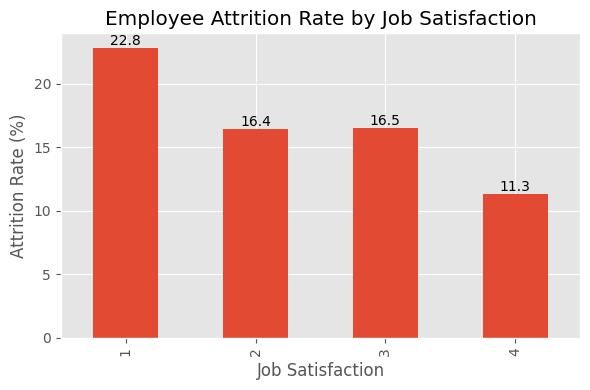

In [69]:
job_sat_rate = (
    pd.crosstab(df["JobSatisfaction"], df["Attrition"], normalize="index") * 100
)

ax = job_sat_rate["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Employee Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Attrition Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

In [70]:
pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
WorkLifeBalance,,
1,68.750000,31.250000
2,83.139535,16.860465
3,85.778275,14.221725
4,82.352941,17.647059


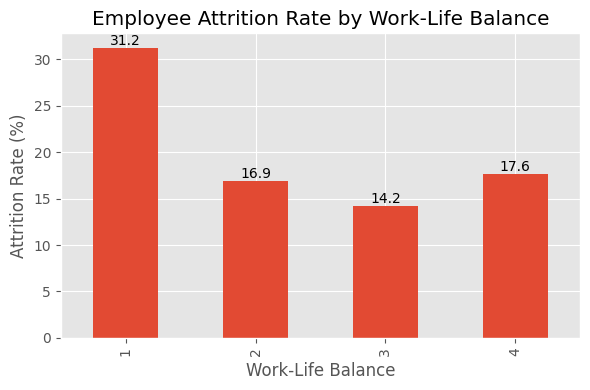

In [71]:
wlb_rate = (
    pd.crosstab(df["WorkLifeBalance"], df["Attrition"], normalize="index") * 100
)

ax = wlb_rate["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Employee Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance")
plt.ylabel("Attrition Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

In [72]:
pd.crosstab(
    df["EnvironmentSatisfaction"],
    df["Attrition"],
    normalize="index"
) * 100

Attrition,No,Yes
EnvironmentSatisfaction,,
1,74.647887,25.352113
2,85.017422,14.982578
3,86.313466,13.686534
4,86.547085,13.452915


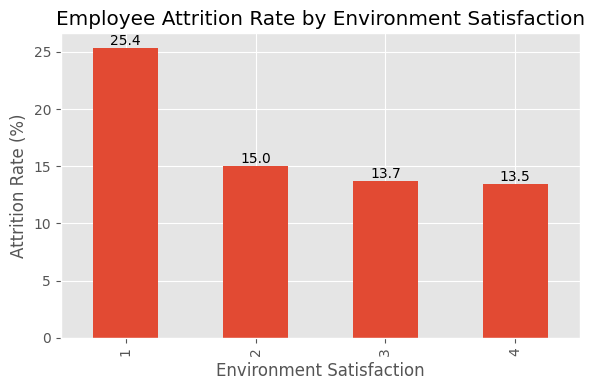

In [73]:
env_rate = (
    pd.crosstab(df["EnvironmentSatisfaction"], df["Attrition"], normalize="index") * 100
)

ax = env_rate["Yes"].plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Employee Attrition Rate by Environment Satisfaction")
plt.xlabel("Environment Satisfaction")
plt.ylabel("Attrition Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

In [74]:
df.groupby("Attrition")["MonthlyIncome"].mean()

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

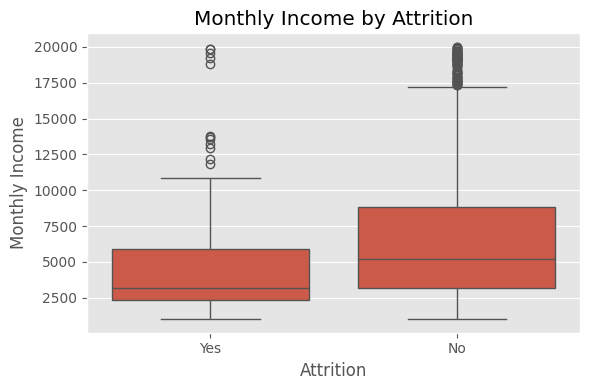

In [75]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.tight_layout()
plt.show()

In [76]:
df.groupby("Attrition")["Age"].mean()

Attrition
No     37.561233
Yes    33.607595
Name: Age, dtype: float64

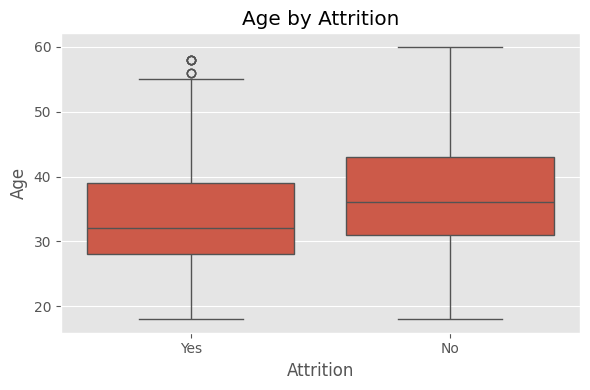

In [77]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Age"
)

plt.title("Age by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

In [78]:
df.groupby("Attrition")["YearsAtCompany"].mean()

Attrition
No     7.369019
Yes    5.130802
Name: YearsAtCompany, dtype: float64

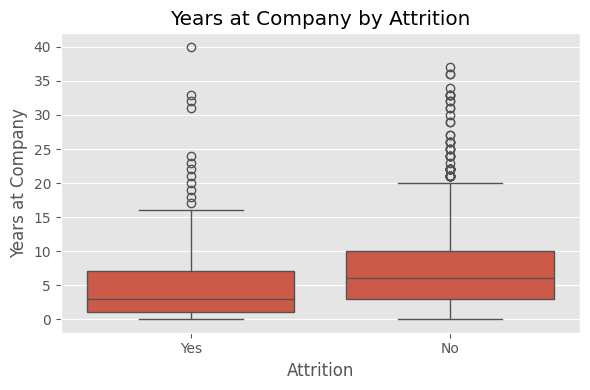

In [79]:
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")

plt.tight_layout()
plt.show()

In [80]:
dept_rate = (
    pd.crosstab(
        df["Department"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

dept_rate

Attrition,No,Yes
Department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


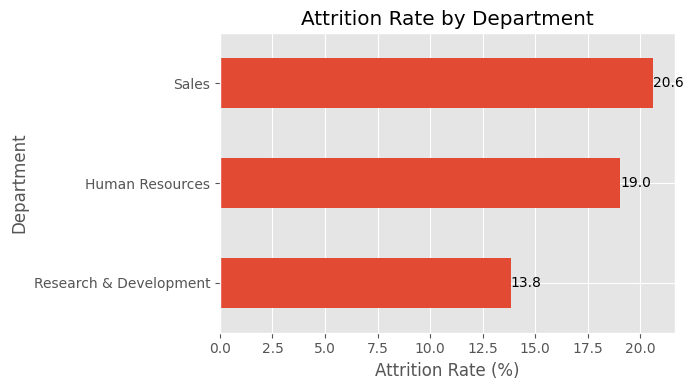

In [81]:
ax = dept_rate["Yes"].sort_values().plot(
    kind="barh",
    figsize=(7,4)
)

plt.title("Attrition Rate by Department")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Department")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

In [82]:
role_rate = (
    pd.crosstab(
        df["JobRole"],
        df["Attrition"],
        normalize="index"
    ) * 100
)

role_rate

Attrition,No,Yes
JobRole,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


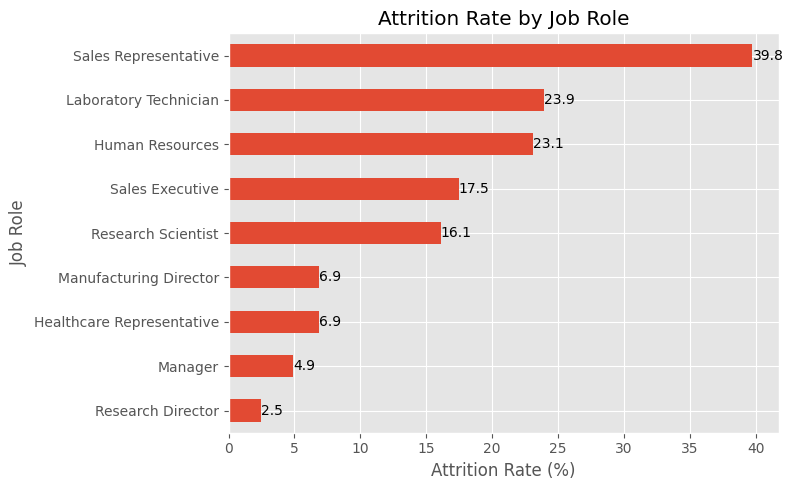

In [83]:
ax = role_rate["Yes"].sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f")

plt.tight_layout()
plt.show()

## Key Insights

- The dataset contains **1,470 employees**, with an overall attrition rate of **16.1%**.
- **Gender** has only a weak association with attrition, indicating it is not a major predictor.
- Employees working **overtime** have nearly **three times higher attrition** than those who do not.
- Lower **job satisfaction** is associated with increased employee attrition.
- Employees reporting poor **work-life balance** are significantly more likely to leave.
- Lower **environment satisfaction** is linked to higher attrition rates.
- Employees who left the company have **lower monthly incomes** on average than those who stayed.
- **Younger employees** and those with **shorter tenure** are more likely to resign.
- The **Sales** department records the highest attrition among departments, while **Research & Development** has the lowest.
- Among job roles, **Sales Representatives** exhibit the highest attrition, whereas **Research Directors** and **Managers** have the lowest.
- Overall, **workplace factors** such as overtime, job satisfaction, work-life balance, work environment, compensation, and experience appear to have a much stronger influence on attrition than demographic characteristics.